In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Set the current and parent paths
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
sys.path.append(parent_path)

# Import custom modules
import funcRotor  # Module for acquiring tidal data from NOAA
import constUnitConvert

# Initialize constants and unit conversion
CONVERT = constUnitConvert.ConstantsUnitConversion()

# Configure matplotlib style
plt.style.use('tableau-colorblind10')


# Using `funcRotor` to Process AeroDyn Output Files

This document guides users on using functions in `funcRotor` to process output files from AeroDyn and to obtain the necessary data for simulating rotor dynamics. The data includes:
- Function of Power Coefficient (Cp)
- Function of Torque Coefficients (Ct)
- Minimum Pressure Coefficients (Cpmin)
- Span ratio (corresponding to the minimum pressure coefficient above)
- Optimal Cp and the corresponding optimal TSR

In [3]:
# Define the path to the AeroDyn folder
AeroDynFolderPath = "../../TurboShipCostCalculator/Original_MHKF1_ARLScaled_20Sections_5ms_VariedPitch_Cp/"

# Define the maximum and minimum Tip Speed Ratio (TSR)
myTSRmax = 10.0
myTSRmin = 0.0

# Load rotor surfaces
CpFunc, CtFunc, CpminFunc, spanRatio, CpOpt, TSROpt = funcRotor.loadRotorSurfaces(AeroDynFolderPath, myTSRmax, myTSRmin)

# Estimate rotor mass
bladeVolume, bladeMass, bladeRadius, bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath)


# Visualizing Rotor Performance

This section demonstrates how to visualize the rotor performance using the `funcRotor` module. The plots include the Power Coefficient (Cp), Thrust Coefficient (Ct), and Minimum Pressure Coefficient (Cpmin) for different span ratios.

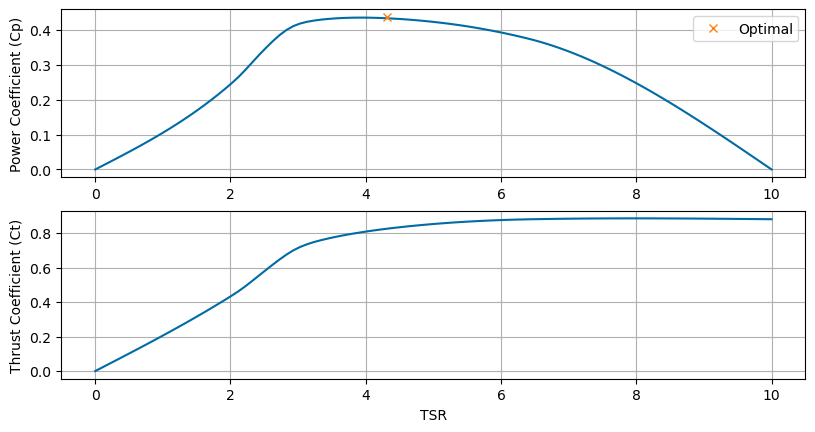

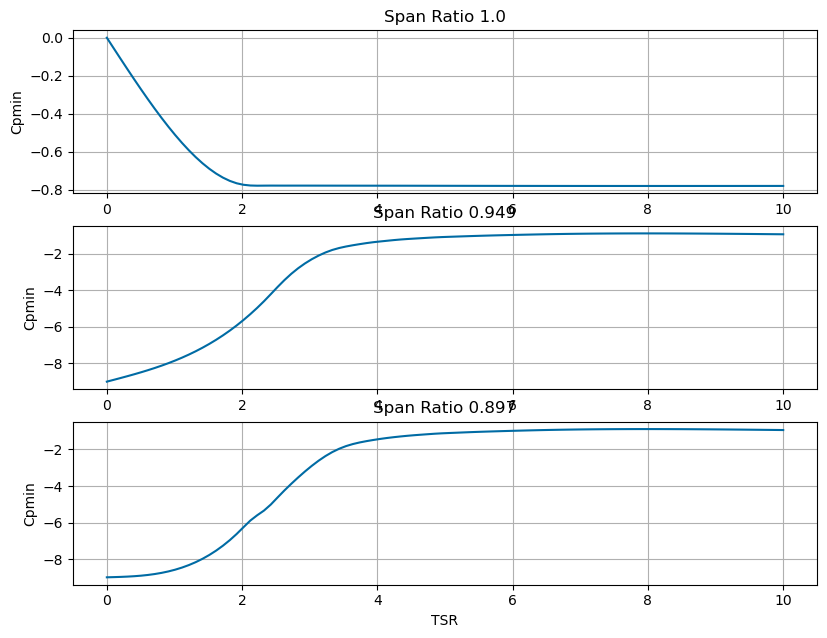

In [4]:
# Create a vector of TSR for use by the equation
TSR_val = np.linspace(myTSRmin, myTSRmax, 100)

# Plot Power Coefficient (Cp) and Thrust Coefficient (Ct)
plt.figure(figsize=(9.6, 4.8))

# Subplot for Power Coefficient (Cp)
plt.subplot(2, 1, 1)
plt.plot(TSR_val, CpFunc(TSR_val))
plt.plot(TSROpt, CpOpt, 'x', label='Optimal')
plt.ylabel('Power Coefficient (Cp)')
plt.grid()
plt.legend()

# Subplot for Thrust Coefficient (Ct)
plt.subplot(2, 1, 2)
plt.plot(TSR_val, CtFunc(TSR_val))
plt.xlabel('TSR')
plt.ylabel('Thrust Coefficient (Ct)')
plt.grid()

# Save the figure as a PDF
plt.savefig("RotorPerformanceMap.pdf", format="pdf", bbox_inches="tight")

# Plot Minimum Pressure Coefficient (Cpmin) for different span ratios
plt.figure(figsize=(9.6, 7.2))

# Subplot for the first span ratio
plt.subplot(3, 1, 1)
plt.plot(TSR_val, CpminFunc[0](TSR_val))
plt.ylabel('Cpmin')
plt.title('Span Ratio ' + str(spanRatio[0]))
plt.grid()

# Subplot for the second span ratio
plt.subplot(3, 1, 2)
plt.plot(TSR_val, CpminFunc[1](TSR_val))
plt.ylabel('Cpmin')
plt.title('Span Ratio ' + str(round(spanRatio[1], 3)))
plt.grid()

# Subplot for the third span ratio
plt.subplot(3, 1, 3)
plt.plot(TSR_val, CpminFunc[2](TSR_val))
plt.xlabel('TSR')
plt.ylabel('Cpmin')
plt.title('Span Ratio ' + str(round(spanRatio[2], 3)))
plt.grid()

# Save the figure as a PDF
plt.savefig("Cpmin.pdf", format="pdf", bbox_inches="tight")


# Estimating Rotor Mass

This section demonstrates how to estimate the rotor mass using the `funcRotor` module. The necessary data is provided in the AeroDyn folder.


In [8]:
# Estimate rotor mass
bladeVolume, bladeMass, bladeRadius, bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath)

# Convert blade volume from cubic meters to cubic centimeters
bladeVolume_cm3 = bladeVolume * CONVERT.m32cm3

# Print the estimated blade properties
print(f'The single blade has an estimated volume of {round(bladeVolume_cm3, 3)} cm^3, '
      f'mass of {round(bladeMass, 3)} kg, and radius of {round(bladeRadius, 3)} m.')


The single blade has an estimated volume of 228.359 cm^3, mass of 0.685 kg, and radius of 0.258 m.


# Visualizing Blade Coordinates in 3D

This section demonstrates how to visualize the blade coordinates in a 3D plot using Matplotlib.


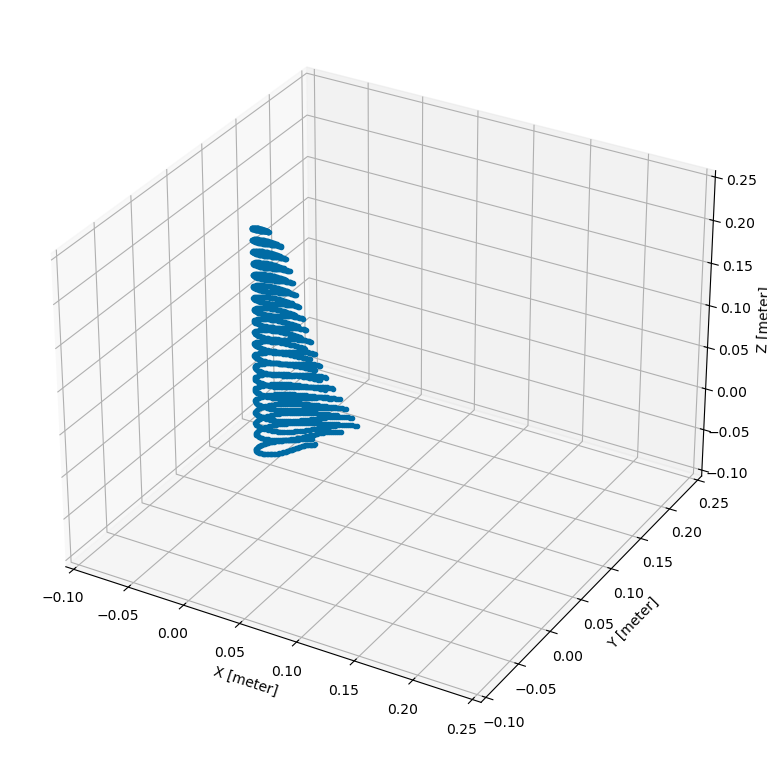

In [9]:
# Create a 3D plot of the blade coordinates
fig = plt.figure(figsize=(9.6, 9.6))
ax = plt.axes(projection='3d')

# Plot defining corner points
ax.plot(bladeCoordinate.T[0], bladeCoordinate.T[1], bladeCoordinate.T[2], '.')

# Set axis labels
ax.set_xlabel('X [meter]')
ax.set_ylabel('Y [meter]')
ax.set_zlabel('Z [meter]')

# Set axis limits
ax.set_xlim([-0.1, 0.25])
ax.set_ylim([-0.1, 0.25])
ax.set_zlim([-0.1, 0.25])

# Show the plot
plt.show()


# Calculating and Visualizing Moment of Inertia and Mass

This section demonstrates how to calculate and visualize the moment of inertia and mass of a rotor blade as functions of its radius using the `funcRotor` module.


Example: Radius of 0.5 [m] has moment of inertia of 1.250662324005989 [kg m^2]


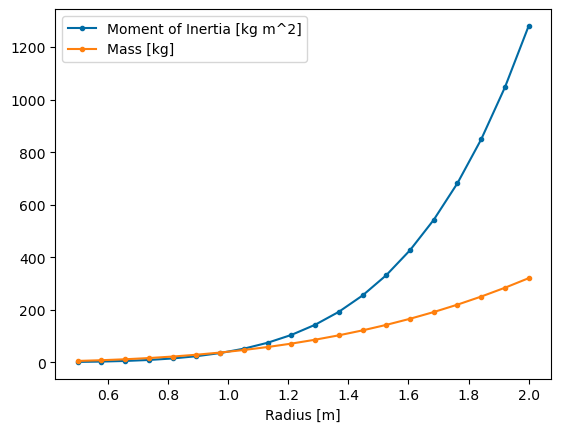

In [10]:
# Define Radius values
Rr_val = np.linspace(0.5, 2.0, 20)

# Calculate moment of inertia and mass
Jr_val, Mass_val = funcRotor.calInertia(Rr_val, bladeRadius, bladeMass, 2)

# Plot moment of inertia and mass as functions of radius
plt.figure()
plt.plot(Rr_val, Jr_val, '.-', label='Moment of Inertia [kg m^2]')
plt.plot(Rr_val, Mass_val, '.-', label='Mass [kg]')
plt.xlabel('Radius [m]')
plt.legend()

# Print example result
print(f'Example: Radius of {Rr_val[0]} [m] has moment of inertia of {Jr_val[0]} [kg m^2]')

# Save the figure as a PDF
plt.savefig("ScaleInertia.pdf", format="pdf", bbox_inches="tight")
